In [21]:
import pandas as pd

dataset_path = r"C:\Users\abc\projects\Cancer Cell Classification Project\Data\expanded_dataset.csv"
df = pd.read_csv(dataset_path)

print(df.shape)
print(df.columns)

(788, 19)
Index(['TableNumber', 'ImageNumber', 'Image_FileName_DAPI',
       'Image_PathName_DAPI', 'Image_FileName_Tubulin',
       'Image_PathName_Tubulin', 'Image_FileName_Actin',
       'Image_PathName_Actin', 'Image_Metadata_Plate_DAPI',
       'Image_Metadata_Well_DAPI', 'Replicate', 'Image_Metadata_Compound',
       'Image_Metadata_Concentration', 'compound', 'concentration', 'moa',
       'DAPI_path', 'Tubulin_path', 'Actin_path'],
      dtype='object')


moa
Microtubule stabilizers      384
Microtubule destabilizers    140
DNA damage                   108
Eg5 inhibitors                84
Aurora kinase inhibitors      72
Name: count, dtype: int64


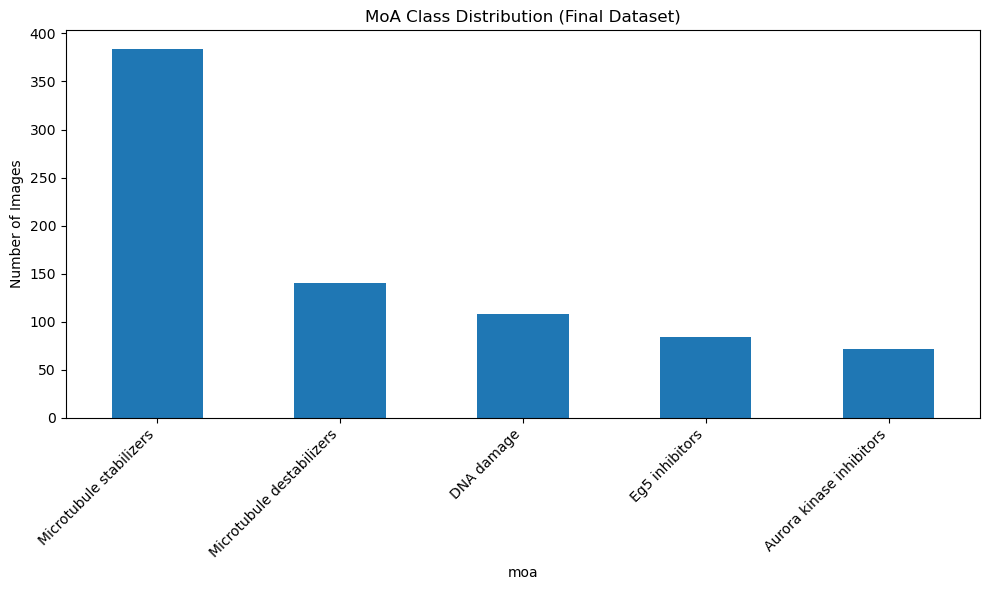

Figure saved to: C:\Users\abc\projects\Cancer Cell Classification Project\Figures\moa_class_distribution_final_dataset.png


In [23]:
import os
import matplotlib.pyplot as plt

FIGURES_DIR = r"C:\Users\abc\projects\Cancer Cell Classification Project\Figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

class_counts = df["moa"].value_counts()
print(class_counts)

plt.figure(figsize=(10, 6))
class_counts.plot(kind="bar")
plt.title("MoA Class Distribution (Final Dataset)")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

save_path = os.path.join(FIGURES_DIR, "moa_class_distribution_final_dataset.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", save_path)

In [27]:
import cv2
import numpy as np

IMG_SIZE = 128

def load_image(row):
    dapi = cv2.imread(row["DAPI_path"], cv2.IMREAD_GRAYSCALE)
    tubulin = cv2.imread(row["Tubulin_path"], cv2.IMREAD_GRAYSCALE)
    actin = cv2.imread(row["Actin_path"], cv2.IMREAD_GRAYSCALE)

    dapi = cv2.resize(dapi, (IMG_SIZE, IMG_SIZE))
    tubulin = cv2.resize(tubulin, (IMG_SIZE, IMG_SIZE))
    actin = cv2.resize(actin, (IMG_SIZE, IMG_SIZE))

    image = np.stack([dapi, tubulin, actin], axis=-1)
    return image

In [29]:
images = []
labels = []

for _, row in df.iterrows():
    img = load_image(row)
    images.append(img)
    labels.append(row["moa"])

X = np.array(images)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (788, 128, 128, 3)
y shape: (788,)


In [31]:
X = X / 255.0
print("X min:", X.min(), "X max:", X.max())

X min: 0.0 X max: 0.9725490196078431


In [33]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['Aurora kinase inhibitors' 'DNA damage' 'Eg5 inhibitors'
 'Microtubule destabilizers' 'Microtubule stabilizers']


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (630, 128, 128, 3)
Test shape: (158, 128, 128, 3)


In [37]:
DATA_DIR = r"C:\Users\abc\projects\Cancer Cell Classification Project\Data"

np.save(os.path.join(DATA_DIR, "X_train.npy"), X_train)
np.save(os.path.join(DATA_DIR, "X_test.npy"), X_test)
np.save(os.path.join(DATA_DIR, "y_train.npy"), y_train)
np.save(os.path.join(DATA_DIR, "y_test.npy"), y_test)

print("Processed arrays saved successfully.")

Processed arrays saved successfully.
